In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder

In [34]:
data=pd.read_csv('datasets/iris.csv',header=None)
data=data.drop(columns=[2,3])
e=LabelEncoder()
data[4]=e.fit_transform(data[4])
data

,0,1,4
0,5.1,3.5,0
1,4.9,3.0,0
2,4.7,3.2,0
3,4.6,3.1,0
4,5.0,3.6,0
...,...,...,...
145,6.7,3.0,2
146,6.3,2.5,2
147,6.5,3.0,2
148,6.2,3.4,2


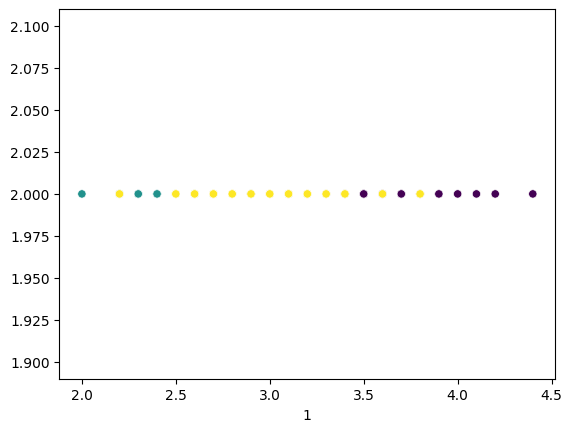

In [35]:
sns.scatterplot(data=data,x=1,y=2,c=data[4])
plt.show()

In [36]:
data=data[data[4]!=0]
x=data.iloc[:,:2]
y=data.iloc[:,-1]
x,y

(       0    1
 50   7.0  3.2
 51   6.4  3.2
 52   6.9  3.1
 53   5.5  2.3
 54   6.5  2.8
 ..   ...  ...
 145  6.7  3.0
 146  6.3  2.5
 147  6.5  3.0
 148  6.2  3.4
 149  5.9  3.0
 
 [100 rows x 2 columns],
 50     1
 51     1
 52     1
 53     1
 54     1
       ..
 145    2
 146    2
 147    2
 148    2
 149    2
 Name: 4, Length: 100, dtype: int64)

In [37]:
m1=LogisticRegression()
m2=RandomForestClassifier()
m3=KNeighborsClassifier()

In [38]:
estimators=[('lr',m1),('rf',m2),('knn',m3)]

In [39]:
for i in  estimators:
    acc=np.mean(cross_val_score(i[1],x,y,cv=5,scoring='accuracy'))
    print(i[0]+" : accuracy = ","{:.2f}".format(acc))

lr : accuracy =  0.74
rf : accuracy =  0.65
knn : accuracy =  0.65


Voting

In [40]:
from sklearn.ensemble import VotingClassifier

In [41]:
m=VotingClassifier(estimators=estimators,voting='hard')
acc=np.mean(cross_val_score(m,x,y,cv=5,scoring='accuracy'))
np.round(acc,2)

np.float64(0.69)

In [42]:
m=VotingClassifier(estimators=estimators,voting='soft')
acc=np.mean(cross_val_score(m,x,y,cv=5,scoring='accuracy'))
np.round(acc,2)

np.float64(0.66)

In [43]:
m=VotingClassifier(estimators=estimators,voting='hard',weights=[5,1,3])
acc=np.mean(cross_val_score(m,x,y,cv=5,scoring='accuracy'))
np.round(acc,2)

np.float64(0.74)

Voting Ensemble for Regression works as it works for Classification